In [2]:
import pathlib
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import sys
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from scipy.stats import wilcoxon, chi2
from statsmodels.formula.api import mixedlm

# Global variables
nmedia = 2
nreplicates=3
im_resolution = 0.62 # µm/pixel
ring_width = 1

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))
blues = sns.color_palette("Blues", 5)[1:4]      
oranges = sns.color_palette("Oranges", 5)[1:4]

# Partener subset
partner_subset = ['G3','GN4','Ct','AlFa','G4','PsAe','PsFu','S1']
partner_subset.sort()

# Setup folders 
proj_dir = pathlib.Path("/home/alessia/Documents/PhD/Colony-project")
cfu_dir = proj_dir / 'cfu_counts' / 'raw_data'
if ring_width == 5:
    plot_dir = proj_dir / 'figures' / 'FullData'
elif ring_width == 1:
    plot_dir = proj_dir / 'figures_ring_1' / 'FullData'
if not plot_dir.exists():
    plot_dir.mkdir(parents=True)
   
# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *

In [3]:
# Partners to remove because Oa dominates in +T
p_to_remove_fa = ['BrVe','G1','G5','GN1','GN3','KlPn','PrRe','SC1','SC18']
p_to_remove_glu = ['AlFa','Ct','S1']

## Load cfu and image analysis data for FA

In [4]:
# Load cfu and image analysis data for FA
all_cfu_files = glob.glob(str(cfu_dir / '*SET*'))
cfu_df = pd.read_excel(all_cfu_files[0])
for file in all_cfu_files[1:]:
    cfu_df2 = pd.read_excel(file)
    cfu_df = pd.concat([cfu_df,cfu_df2])
cfu_df.reset_index(drop=True,inplace=True)
cfu_df = cfu_df[cfu_df['partner'] != "OaWT"]
cfu_df = cfu_df[cfu_df['strain'] != "OaWT"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-control"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-border"]
cfu_df = cfu_df[cfu_df['condition'] != "FAT-border"].copy()
cfu_df.head()

,strain,replicate,condition,culture,partner,dilution,count,day,comments,CFUs,SET
0,Oa,1,FA-FAT,mono,none,4.0,70.0,0.0,NaN,70000.0,3
1,G3,1,FA-FAT,mono,none,4.0,59.0,0.0,NaN,59000.0,3
2,G4,1,FA-FAT,mono,none,4.0,67.0,0.0,NaN,67000.0,3
3,G5,1,FA-FAT,mono,none,4.0,28.0,0.0,NaN,28000.0,3
4,G6,1,FA-FAT,mono,none,4.0,69.0,0.0,NaN,69000.0,3


In [5]:
partners_fa = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_fa = [p for p in partners_fa if p != "Oa"]
rows = []
for partner in partners_fa:
    for media in ['FAT','FA']:
        for rep in range(1, nreplicates + 1):
            oa_on_p = get_oa_on_p(cfu_df, media, partner, rep)
            p_on_oa = get_p_on_oa(cfu_df, media, partner, rep) 
            p_yield = get_p_yield(cfu_df, media, partner, rep) 
            oa_yield = get_oa_yield(cfu_df, media, rep) 
            thiamin = 1 if media == 'FAT' else 0
            rows.append({'partner':partner,'carbon_source':'FA', 'salt':1 ,'thiamin':thiamin,'oa_on_p':oa_on_p,'p_on_oa':p_on_oa,'p_yield':p_yield,'oa_yield':oa_yield,'replicate':rep})
cfu_values_fa = pd.DataFrame(rows)
cfu_values_fa.head()   

,partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield,replicate
0,G3,FA,1,1,-1.075251,-0.096910,4.872601,5.215600,1
1,G3,FA,1,1,-1.181055,-0.065063,4.507902,5.268845,2
2,G3,FA,1,1,-1.152091,-0.073926,4.691546,5.301030,3
3,G3,FA,1,0,-0.169142,1.266268,4.720510,2.967815,1
4,G3,FA,1,0,-0.093422,1.141329,4.734298,2.836143,2


In [6]:
# Load image analysis data
if ring_width == 5:
    data_fa = pd.read_csv('../AllSets_FA/fa_image_analysis.csv')
elif ring_width == 1:
    data_fa = pd.read_csv('../AllSets_FA/fa_image_analysis_ring_1.csv')
data_fa["carbon_source"] = "FA"
data_fa["salt"] = 1
data_fa["thiamin"] = data_fa["media"].apply(lambda x: 1 if x == "FAT" else 0)
data_fa.drop(columns=['media','intermixing_indices','rings'], inplace=True)
data_fa.head()

,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin
0,AeCa,1,0.020642,507.270323,34.708377,0.858366,FA,1,1
1,AeCa,2,0.023708,320.718093,29.296464,0.859579,FA,1,1
2,AeCa,3,0.021737,854.628492,27.016859,0.903959,FA,1,1
3,AeCa,1,0.042457,145.375508,13.512418,0.848801,FA,1,0
4,AeCa,2,0.042431,445.143851,13.538552,0.863393,FA,1,0


In [7]:
# Merge the two dataframes
data_fa = pd.merge(data_fa, cfu_values_fa, on=['partner','carbon_source','salt','thiamin','replicate'], how='inner')
print(f"Number of rows in FA data: {len(data_fa)}")
del cfu_df, cfu_values_fa
data_fa.head()

Number of rows in FA data: 168


,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,AeCa,1,0.020642,507.270323,34.708377,0.858366,FA,1,1,-1.087150,-0.328304,3.509914,5.215600
1,AeCa,2,0.023708,320.718093,29.296464,0.859579,FA,1,1,-1.087150,-0.297270,3.501945,5.268845
2,AeCa,3,0.021737,854.628492,27.016859,0.903959,FA,1,1,-1.050167,-0.361728,3.387599,5.301030
3,AeCa,1,0.042457,145.375508,13.512418,0.848801,FA,1,0,-0.262685,1.820555,3.582464,2.967815
4,AeCa,2,0.042431,445.143851,13.538552,0.863393,FA,1,0,-0.321552,1.789147,3.547702,2.836143


## Load cfu and image analysis data for FAns


In [8]:
# Load cfu and image analysis data for FAns
remove_psae = True
remove_alfa = False
# CFU counts
cfu_df = pd.read_csv(cfu_dir / '20260602_NOSALT.csv')
# remove PsAe from the data
if remove_psae:
    cfu_df = cfu_df[(cfu_df["strain"]!="PsAe")&(cfu_df["partner"] != "PsAe")]
if remove_alfa:
    cfu_df = cfu_df[(cfu_df["strain"]!="AlFa")&(cfu_df["partner"] != "AlFa")]

# Load image analysis data
if ring_width == 5:
    data_im = pd.read_csv('../20260601_D5_NOSALT/fa_ns_image_analysis.csv')
elif ring_width == 1:
    data_im = pd.read_csv('../20260601_D5_NOSALT/fa_ns_image_analysis_ring_1.csv')
# rmove PsAe from the data
if remove_psae:
    data_im = data_im[(data_im["partner"]!="PsAe")]
if remove_alfa:
    data_im = data_im[(data_im["partner"]!="AlFa")]

In [9]:
# Create a dataframe containing a row for each partner and condition, and having as columns the effect of partner on Oa, te effect of Oa on partner, and the partner monoculure yield
partners_fa_ns = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_fa_ns = [p for p in partners_fa_ns if p != "Oa"]
rows = []
for partner in partners_fa_ns:
    for media in ['FAT_ns','FA_ns']:
        for rep in range(1, nreplicates + 1):
            oa_on_p = get_oa_on_p(cfu_df, media, partner, rep) 
            p_on_oa = get_p_on_oa(cfu_df, media, partner, rep) 
            p_yield = get_p_yield(cfu_df, media, partner, rep) 
            oa_yield = get_oa_yield(cfu_df, media, rep) 
            thiamin = 1 if media == 'FAT_ns' else 0
            rows.append({'partner':partner,'carbon_source':'FA', 'salt':0 ,'thiamin':thiamin,'oa_on_p':oa_on_p,'p_on_oa':p_on_oa,'p_yield':p_yield,'oa_yield':oa_yield,'replicate':rep})
cfu_values = pd.DataFrame(rows)
cfu_values.head()  

,partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield,replicate
0,G3,FA,0,1,0.000000,-1.066947,4.539912,5.221849,1
1,G3,FA,0,1,0.116506,-1.000000,4.467361,5.215600,2
2,G3,FA,0,1,0.062148,-0.970037,4.539912,5.147603,3
3,G3,FA,0,0,0.218056,1.104735,4.486667,2.895265,1
4,G3,FA,0,0,-0.106455,1.012965,4.681241,2.933053,2


In [10]:
# Create a dataframe containing a row for each partner and condition, and having as columns the mean mixing, mean Oa frequency, mean Oa sector size and mean partner sector size
data_im["carbon_source"] = "FA"
data_im["salt"] = 0
data_im["thiamin"] = data_im["media"].apply(lambda x: 1 if x == "FAT_ns" else 0)
data_im.drop(columns=['media','intermixing_indices','rings'], inplace=True)
data_im.head()

,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin
0,AlFa,1,0.054473,8.297479,438.478696,0.044944,FA,0,1
1,AlFa,2,0.052602,8.483350,524.421299,0.044131,FA,0,1
2,AlFa,3,0.019521,7.683632,715.188098,0.039708,FA,0,1
3,AlFa,1,0.000000,7.699487,736.393627,0.019002,FA,0,0
4,AlFa,2,0.070987,7.042870,492.819915,0.023468,FA,0,0


In [11]:
# Merge the two dataframes
data_fa_ns = pd.merge(data_im, cfu_values, on=['partner','carbon_source','salt','thiamin','replicate'], how='inner')
print(f"Number of rows in FA NS data: {len(data_fa_ns)}")
del cfu_df, cfu_values, data_im
data_fa_ns.head()

Number of rows in FA NS data: 42


,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,AlFa,1,0.054473,8.297479,438.478696,0.044944,FA,0,1,-0.049218,-2.367977,5.432918,5.221849
1,AlFa,2,0.052602,8.483350,524.421299,0.044131,FA,0,1,-0.124939,-2.522879,5.377870,5.215600
2,AlFa,3,0.019521,7.683632,715.188098,0.039708,FA,0,1,-0.043466,-2.301030,5.365971,5.147603
3,AlFa,1,0.000000,7.699487,736.393627,0.019002,FA,0,0,-0.055223,-0.559473,5.334713,2.895265
4,AlFa,2,0.070987,7.042870,492.819915,0.023468,FA,0,0,0.025184,-0.594235,5.328182,2.933053


## Load cfu and image analysis data for Glu


In [12]:
# Load cfu and image analysis data for Glu
remove_psae = True
remove_g3 = True
# CFU counts
cfu_df = pd.read_csv(cfu_dir / '20260616_GLUCOSE.csv')
# remove PsAe from the data
if remove_psae:
    cfu_df = cfu_df[(cfu_df["strain"]!="PsAe")&(cfu_df["partner"] != "PsAe")]
if remove_g3:
    cfu_df = cfu_df[(cfu_df["strain"]!="G3")&(cfu_df["partner"] != "G3")]

# Load image analysis data
if ring_width == 5:
    data_im = pd.read_csv('../20260615_D5_GLUCOSE/glu_image_analysis.csv')
elif ring_width == 1:
    data_im = pd.read_csv('../20260615_D5_GLUCOSE/glu_image_analysis_ring_1.csv')
# remove PsAe from the data
if remove_psae:
    data_im = data_im[(data_im["partner"]!="PsAe")]
if remove_g3:
    data_im = data_im[(data_im["partner"]!="G3")]

In [13]:
# Create a dataframe containing a row for each partner and condition, and having as columns the effect of partner on Oa, te effect of Oa on partner, and the partner monoculure yield
partners_glu = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_glu = [p for p in partners_glu if p != "Oa"]
rows = []
for partner in partners_glu:
    for media in ['GluT','Glu']:
        for rep in range(1, nreplicates + 1):
            oa_on_p = get_oa_on_p(cfu_df, media, partner, rep) 
            p_on_oa = get_p_on_oa(cfu_df, media, partner, rep) 
            p_yield = get_p_yield(cfu_df, media, partner, rep) 
            oa_yield = get_oa_yield(cfu_df, media, rep) 
            thiamin = 1 if media == 'GluT' else 0
            rows.append({'partner':partner,'carbon_source':'Glu', 'salt':1 ,'thiamin':thiamin,'oa_on_p':oa_on_p,'p_on_oa':p_on_oa,'p_yield':p_yield,'oa_yield':oa_yield,'replicate':rep})
cfu_values_glu = pd.DataFrame(rows)
cfu_values_glu.head()

,partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield,replicate
0,GN4,Glu,1,1,-0.615424,-0.410174,4.477121,5.653213,1
1,GN4,Glu,1,1,-0.439333,-0.341459,4.356547,5.676694,2
2,GN4,Glu,1,1,-0.673416,-0.255273,4.463757,5.676694,3
3,GN4,Glu,1,0,-0.449969,1.746552,4.449969,3.375664,1
4,GN4,Glu,1,0,-0.260913,1.645526,4.477121,3.439333,2


In [14]:
# Create a dataframe containing a row for each partner and condition, and having as columns the mean mixing, mean Oa frequency, mean Oa sector size and mean partner sector size
data_im["carbon_source"] = "Glu"
data_im["salt"] = 1
data_im["thiamin"] = data_im["media"].apply(lambda x: 1 if x == "GluT" else 0)
data_im.drop(columns=['media','intermixing_indices','rings'], inplace=True)
data_im.head()

,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin
0,AlFa,1,0.000000,1342.704965,2.224823,0.999335,Glu,1,1
1,AlFa,2,0.000000,1971.245625,7.548125,0.996256,Glu,1,1
2,AlFa,3,0.000000,1655.905405,3.094595,0.999560,Glu,1,1
3,AlFa,1,0.322796,213.337871,5.387881,0.945646,Glu,1,0
4,AlFa,2,0.232025,116.061214,6.404579,0.900657,Glu,1,0


In [15]:
# Merge the two dataframes
data_glu = pd.merge(data_im, cfu_values_glu, on=['partner','carbon_source','salt','thiamin','replicate'], how='inner')
print(f"Number of rows in Glu data: {len(data_glu)}")
del cfu_df, cfu_values_glu
data_glu.head()

Number of rows in Glu data: 36


,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,AlFa,1,0.000000,1342.704965,2.224823,0.999335,Glu,1,1,-0.905024,-0.194575,4.176091,5.653213
1,AlFa,2,0.000000,1971.245625,7.548125,0.996256,Glu,1,1,-1.096910,-0.093905,4.054358,5.676694
2,AlFa,3,0.000000,1655.905405,3.094595,0.999560,Glu,1,1,-0.954243,-0.141329,4.091080,5.676694
3,AlFa,1,0.322796,213.337871,5.387881,0.945646,Glu,1,0,0.956534,2.168404,4.146128,3.375664
4,AlFa,2,0.232025,116.061214,6.404579,0.900657,Glu,1,0,0.677781,2.063669,4.124939,3.439333


## Create complete dataframe

In [16]:
data_full = pd.concat([data_fa, data_fa_ns, data_glu])
carbon_source_mapping = {'FA':0,'Glu':1}
data_full['carbon_source'] = data_full['carbon_source'].map(carbon_source_mapping)
data_full["log_sector"] = np.log(data_full["sector_size_Oa"])
data_full["sector_size_Oa_um"] = data_full["sector_size_Oa"] * im_resolution
data_full["log_sector_um"] = data_full["log_sector"] + np.log(im_resolution)
data_full.head()

,partner,replicate,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield,log_sector,sector_size_Oa_um,log_sector_um
0,AeCa,1,0.020642,507.270323,34.708377,0.858366,0,1,1,-1.087150,-0.328304,3.509914,5.215600,6.229044,314.507601,5.751008
1,AeCa,2,0.023708,320.718093,29.296464,0.859579,0,1,1,-1.087150,-0.297270,3.501945,5.268845,5.770563,198.845218,5.292527
2,AeCa,3,0.021737,854.628492,27.016859,0.903959,0,1,1,-1.050167,-0.361728,3.387599,5.301030,6.750667,529.869665,6.272631
3,AeCa,1,0.042457,145.375508,13.512418,0.848801,0,1,0,-0.262685,1.820555,3.582464,2.967815,4.979320,90.132815,4.501284
4,AeCa,2,0.042431,445.143851,13.538552,0.863393,0,1,0,-0.321552,1.789147,3.547702,2.836143,6.098397,275.989188,5.620362


In [17]:
# Divide interactions between faiclitation and competition
data_full['oa_on_p_facilitation'] = data_full['oa_on_p'].apply(lambda x: x if x > 0.1 else 0)
data_full['oa_on_p_competition'] = data_full['oa_on_p'].apply(lambda x: x if x < -0.1 else 0)
data_full['p_on_oa_facilitation'] = data_full['p_on_oa'].apply(lambda x: x if x > 0.1 else 0)
data_full['p_on_oa_competition'] = data_full['p_on_oa'].apply(lambda x: x if x < -0.1 else 0)

In [18]:
# Create dataframe for analysis
cols = ['partner','carbon_source','salt','thiamin','oa_on_p','p_on_oa','oa_on_p_facilitation','oa_on_p_competition','p_on_oa_facilitation','p_on_oa_competition','p_yield','oa_yield','mean_intermixing','log_sector','log_sector_um','oa_frequency','sector_size_Oa','sector_size_Oa_um','replicate']
df = data_full[cols].dropna().reset_index(drop=True)
df["thiamin_str"] = df["thiamin"].apply(lambda x: "+T" if x==1 else "-T")
df["rel_yield"] = df["oa_yield"] - df["p_yield"]
# remove partners that are dominated by Oa in +T
df_removed = df[((df['partner'].isin(p_to_remove_fa)) & (df['carbon_source']==0) & (df['salt']==1)) | ((df['partner'].isin(p_to_remove_glu)) & (df['carbon_source']==1) & (df['salt']==1))]
df = df[~((df['partner'].isin(p_to_remove_fa)) & (df['carbon_source']==0) & (df['salt']==1))]
df = df[~((df['partner'].isin(p_to_remove_glu)) & (df['carbon_source']==1) & (df['salt']==1))]

In [19]:
def assign_condition(row):
    if row['salt'] == 0:
        return 'S=0'
    else:
        if row['carbon_source'] == 0:
            return 'CS=FA'
        else:
            return 'CS=Glu'
df["condition"] = df.apply(assign_condition, axis=1)

## Mixed-effect model of Oa sector vs Oa frequency

                 Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     log_sector_um
No. Observations:     174         Method:                 ML           
No. Groups:           19          Scale:                  0.1475       
Min. group size:      6           Log-Likelihood:         -105.3793    
Max. group size:      18          Converged:              Yes          
Mean group size:      9.2                                              
-----------------------------------------------------------------------
                              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     2.881    0.118 24.375 0.000  2.649  3.113
C(thiamin)[T.1]               0.401    0.062  6.478 0.000  0.279  0.522
freq_centered                 2.121    0.284  7.462 0.000  1.564  2.678
freq_centered:C(thiamin)[T.1] 1.469    0.265  5.543 0.000  0.949  1.988
Group Var

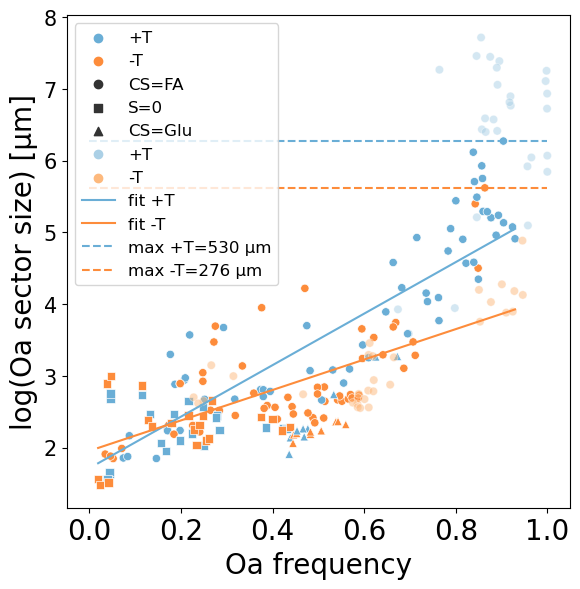

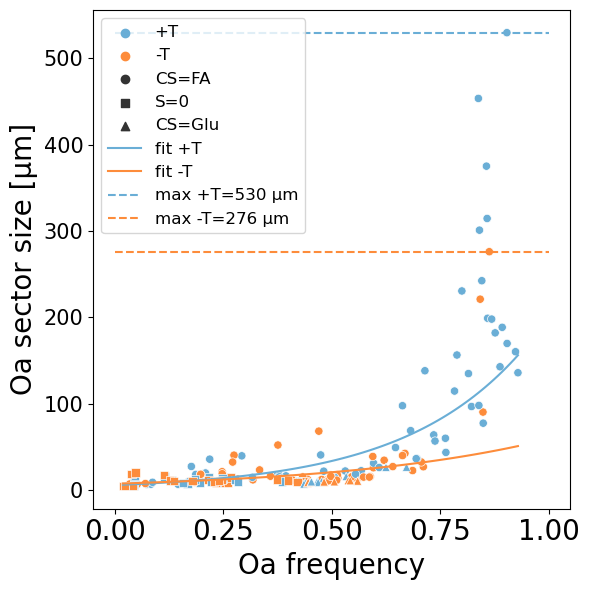

In [20]:
# Mixed model: random intercept for partner
df["freq_centered"] = (
    df["oa_frequency"] - df["oa_frequency"].mean()
)

oa_thresh = 1.01 #np.quantile(df[df["thiamin"]==0]["oa_frequency"], 0.9) #no need for oa_thresh if partners are removed manually

model = smf.mixedlm(
    "log_sector_um ~ freq_centered * C(thiamin)", 
    data=df[df["oa_frequency"]<oa_thresh],
    groups=df[df["oa_frequency"]<oa_thresh]["partner"],
    re_formula="1"
)

result = model.fit(reml=False)

print(result.summary())

# Exatrct slopes and pvalues from summary
intercept, intercept_pvalue = result.params["Intercept"], result.pvalues["Intercept"]
slope_fa, slope_pvalue = result.params["freq_centered"], result.pvalues["freq_centered"]
additional_slope_fat, additional_slope_pvalue = result.params["freq_centered:C(thiamin)[T.1]"], result.pvalues["freq_centered:C(thiamin)[T.1]"]
additional_intercept_fat, additional_intercept_pvalue = result.params["C(thiamin)[T.1]"], result.pvalues["C(thiamin)[T.1]"]
print(f"Intercept FA: {intercept:.02f} (p={intercept_pvalue}), Slope FA: {slope_fa:.02f} (p={slope_pvalue})")
print(f"Additional intercept FAT: {additional_intercept_fat:.02f} (p={additional_intercept_pvalue}), Additional slope FAT: {additional_slope_fat:.02f} (p={additional_slope_pvalue})")

# Interclass correlation coefficient (ICC)
var_random = result.cov_re.iloc[0, 0]
var_residual = result.scale
icc = var_random / (var_random + var_residual)
print(f"Interclass correlation coefficient (ICC): {icc:.4f}")

# Plot log sector size
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(
    data=df[df["oa_frequency"]<oa_thresh],
    x="oa_frequency",
    y="log_sector_um",
    hue="thiamin_str",
    palette={"+T": blues[1], "-T": oranges[1]},
    style="condition",
    markers=["o", "s", "^"],
    ax=ax
)

sns.scatterplot(
    data=df_removed,
    x="oa_frequency",
    y="log_sector_um",
    color="gray",
    hue="thiamin_str",
    palette={"+T": blues[0], "-T": oranges[0]},
    alpha=0.5,
    ax=ax
)

x_value = np.linspace(df[df["oa_frequency"]<oa_thresh]["oa_frequency"].min(), df[df["oa_frequency"]<oa_thresh]["oa_frequency"].max(), 100)
plt.plot(x_value, intercept + additional_intercept_fat + (slope_fa + additional_slope_fat) * (x_value-df["oa_frequency"].mean()), color=blues[1],label="fit +T")
plt.plot(x_value, intercept + slope_fa * (x_value-df["oa_frequency"].mean()), color=oranges[1], label="fit -T")
ax.set_xlabel("Oa frequency")
ax.set_ylabel("log(Oa sector size) [µm]")
ax.hlines(y=np.log(np.max(df[(df["thiamin"] == 1)&(df["oa_frequency"]<oa_thresh)]["sector_size_Oa_um"])), xmin=0, xmax=1, color=blues[1], linestyle="dashed", label=f"max +T={np.max(df[df['thiamin_str'] == '+T']['sector_size_Oa'])*im_resolution:.0f} µm")
ax.hlines(y=np.log(np.max(df[(df["thiamin"] == 0)&(df["oa_frequency"]<oa_thresh)]["sector_size_Oa_um"])), xmin=0, xmax=1, color=oranges[1], linestyle="dashed", label=f"max -T={np.max(df[df['thiamin_str'] == '-T']['sector_size_Oa'])*im_resolution:.0f} µm")
handles, labels = ax.get_legend_handles_labels()
new_handles = handles[1:3] + handles[4:13]
new_labels = labels[1:3] + labels[4:13]
plt.legend(handles=new_handles, labels=new_labels, fontsize=12)
plt.tight_layout()
plt.savefig(plot_dir / f"log_oa_ss_vs_oa_freq.pdf", dpi=300)
plt.show()

# Plot in linear scale
fig, ax = plt.subplots(figsize=(6,6))

sns.scatterplot(
    data=df[df["oa_frequency"]<oa_thresh],
    x="oa_frequency",
    y="sector_size_Oa_um",
    hue="thiamin_str",
    palette={"+T": blues[1], "-T": oranges[1]},
    style="condition",
    markers=["o", "s", "^"],
    ax=ax
)

# sns.scatterplot(
#     data=df_removed,
#     x="oa_frequency",
#     y="sector_size_Oa_um",
#     hue="thiamin_str",
#     palette={"+T": blues[0], "-T": oranges[0]},
#     alpha=0.5,
#     ax=ax
# )

x_value = np.linspace(df[df["oa_frequency"]<oa_thresh]["oa_frequency"].min(), df[df["oa_frequency"]<oa_thresh]["oa_frequency"].max(), 100)
plt.plot(x_value, np.exp(intercept + additional_intercept_fat + (slope_fa + additional_slope_fat) * (x_value-df["oa_frequency"].mean())), color=blues[1],label="fit +T")
plt.plot(x_value, np.exp(intercept + slope_fa * (x_value-df["oa_frequency"].mean())), color=oranges[1], label="fit -T")
ax.set_xlabel("Oa frequency")
ax.set_ylabel("Oa sector size [µm]")
ax.hlines(y=np.max(df[(df["thiamin"] == 1)&(df["oa_frequency"]<oa_thresh)]["sector_size_Oa_um"]), xmin=0, xmax=1, color=blues[1], linestyle="dashed", label=f"max +T={np.max(df[df['thiamin_str'] == '+T']['sector_size_Oa_um']):.0f} µm")
ax.hlines(y=np.max(df[(df["thiamin"] == 0)&(df["oa_frequency"]<oa_thresh)]["sector_size_Oa_um"]), xmin=0, xmax=1, color=oranges[1], linestyle="dashed", label=f"max -T={np.max(df[df['thiamin_str'] == '-T']['sector_size_Oa_um']):.0f} µm")
handles, labels = ax.get_legend_handles_labels()
new_handles = handles[1:3] + handles[4:11]
new_labels = labels[1:3] + labels[4:11]
plt.legend(handles=new_handles, labels=new_labels, fontsize=12)
plt.tight_layout()
plt.savefig(plot_dir / f"oa_ss_vs_oa_freq.pdf", dpi=300)
plt.show()

In [22]:
# Variance of fixed-effect predictions
fixed_pred = result.model.exog @ result.fe_params # Predicted values from fixed effects
var_fixed = np.var(fixed_pred)

# Random-intercept variance
var_random = result.cov_re.iloc[0, 0]

# Residual variance
var_resid = result.scale

R2_marginal = var_fixed / (
    var_fixed + var_random + var_resid
)

R2_conditional = (var_fixed + var_random) / (
    var_fixed + var_random + var_resid
)

print("Marginal R²:", R2_marginal) #variance explained by fixed effects only
print("Conditional R²:", R2_conditional) #variance explained by fixed and random effects

Marginal R²: 0.6582662618339601
Conditional R²: 0.8658461648916393


In [23]:
# Equivalent OLS model for comparison
ols = smf.ols(
    "log_sector ~ freq_centered * C(thiamin)",
    data=df
).fit()

print("OLS AIC:", ols.aic)
print("Mixed AIC:", result.aic)
print("Mixed - OLS AIC:", result.aic - ols.aic)

print("OLS BIC:", ols.bic)
print("Mixed BIC:", result.bic)
print("Mixed - OLS BIC:", result.bic - ols.bic)

# log likelihood ratio test
print("OLS log-likelihood:", ols.llf)
print("Mixed log-likelihood:", result.llf)
llr = 2 * (result.llf - ols.llf)
df_diff = result.df_modelwc - ols.df_model
p_value = chi2.sf(llr, df_diff)
print(f"Log-likelihood ratio test: LLR={llr}, df={df_diff}, p-value={p_value}")

OLS AIC: 320.32260482551783
Mixed AIC: 222.7585608971208
Mixed - OLS AIC: -97.56404392839704
OLS BIC: 332.95882602237594
Mixed BIC: 241.71289269240796
Mixed - OLS BIC: -91.24593332996798
OLS log-likelihood: -156.16130241275891
Mixed log-likelihood: -105.3792804485604
Log-likelihood ratio test: LLR=101.56404392839704, df=2.0, p-value=8.823646100399472e-23


## Mixed-effect model of Oa sector size vs p on Oa

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      log_sector_um
No. Observations:      174          Method:                  ML           
No. Groups:            19           Scale:                   0.2484       
Min. group size:       6            Log-Likelihood:          -152.8392    
Max. group size:       18           Converged:               Yes          
Mean group size:       9.2                                                
--------------------------------------------------------------------------
                                 Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        2.235    0.227  9.836 0.000  1.789  2.680
C(thiamin)[T.1]                  2.779    0.256 10.843 0.000  2.277  3.281
p_on_oa_centered                 0.586    0.138  4.259 0.000  0.317  0.856
p_on_oa_centered:C(thiamin)[T.1] 0.832    0.

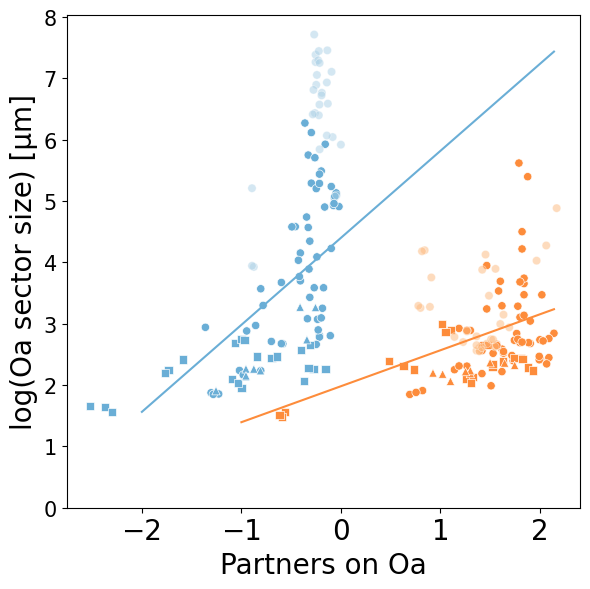

In [24]:
# Mixed model: random intercept for partner
df["p_on_oa_centered"] = df["p_on_oa"] - df["p_on_oa"].mean()

model = smf.mixedlm(
    "log_sector_um ~ p_on_oa_centered*C(thiamin)", 
    data=df[df["oa_frequency"]<oa_thresh],
    groups=df[df["oa_frequency"]<oa_thresh]["partner"],
    re_formula="1"
)

result = model.fit(reml=False)
print(result.summary())

# extract p-value for all terms
intercept_p_value = result.pvalues["Intercept"]
slope_p_value = result.pvalues["p_on_oa_centered"]
intercept_thi_p_value = result.pvalues["C(thiamin)[T.1]"]
slope_thi_p_value = result.pvalues["p_on_oa_centered:C(thiamin)[T.1]"]

# Exatrct slopes and interxepts from summary
intercept = result.params["Intercept"]
slope_fa = result.params["p_on_oa_centered"]
additional_slope_fat = result.params["p_on_oa_centered:C(thiamin)[T.1]"]
additional_intercept_fat = result.params["C(thiamin)[T.1]"]
slope_fat = slope_fa + additional_slope_fat
intercept_fat = intercept + additional_intercept_fat

print(f"Intercept FA: {intercept:.02f} (p={intercept_p_value}), Slope FA: {slope_fa:.02f} (p={slope_p_value})")
print(f"Additional intercept FAT: {additional_intercept_fat:.02f} (p={intercept_thi_p_value}), Additional slope FAT: {additional_slope_fat:.02f} (p={slope_thi_p_value})")

# Interclass correlation coefficient (ICC)
var_random = result.cov_re.iloc[0, 0]
var_residual = result.scale
icc = var_random / (var_random + var_residual)
print(f"Interclass correlation coefficient (ICC): {icc:.4f}")
fig, ax = plt.subplots(figsize=(6,6))

# Raw data
sns.scatterplot(
    data=df[df["oa_frequency"]<oa_thresh],
    x="p_on_oa",
    y="log_sector_um",
    hue="thiamin_str",
    palette={"+T": blues[1], "-T": oranges[1]},
    style="condition",
    markers=["o", "s", "^"],
    ax=ax
)
sns.scatterplot(
    data=df_removed,
    x="p_on_oa",
    y="log_sector_um",
    hue="thiamin_str",
    palette={"+T": blues[0], "-T": oranges[0]},
    alpha=0.5,
    ax=ax
)

x_value_fa = np.linspace(-1, df["p_on_oa"].max(), 100)
x_value_fat = np.linspace(-2, df["p_on_oa"].max(), 100)
plt.plot(x_value_fat, intercept_fat + slope_fat * (x_value_fat-df["p_on_oa"].mean()), color=blues[1],label="fit FAT")
plt.plot(x_value_fa, intercept + slope_fa * (x_value_fa-df["p_on_oa"].mean()), color=oranges[1], label="fit FA")
ax.set_xlabel("Partners on Oa")
ax.set_ylabel("log(Oa sector size) [µm]")
handles, labels = ax.get_legend_handles_labels()
new_handles = handles[1:3] + handles[4:9]
new_labels = labels[1:3] + labels[4:9]
# ax.hlines(y=np.log(np.max(df[df["thiamin"] == 1]["sector_size_Oa"])), xmin=0, xmax=1, color=blues[1], linestyle="dashed", label=f"max FAT={np.max(df[df['thiamin_str'] == '+T']['sector_size_Oa'])*im_resolution:.0f} µm")
# ax.hlines(y=np.log(np.max(df[df["thiamin"] == 0]["sector_size_Oa"])), xmin=0, xmax=1, color=oranges[1], linestyle="dashed", label=f"max FA={np.max(df[df['thiamin_str'] == '-T']['sector_size_Oa'])*im_resolution:.0f} µm")
# plt.legend(handles=new_handles, labels=new_labels, fontsize=12)
plt.legend([],[],frameon=False)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(plot_dir / f"log_oa_ss_vs_p_on_oa.pdf", dpi=300)
plt.show()


In [43]:
np.exp(0.57)

1.768267051433735

In [44]:
np.exp(0.98)

2.664456241929417

In [27]:
# Variance of fixed-effect predictions
fixed_pred = result.model.exog @ result.fe_params # Predicted values from fixed effects
var_fixed = np.var(fixed_pred)

# Random-intercept variance
var_random = result.cov_re.iloc[0, 0]

# Residual variance
var_resid = result.scale

R2_marginal = var_fixed / (
    var_fixed + var_random + var_resid
)

R2_conditional = (var_fixed + var_random) / (
    var_fixed + var_random + var_resid
)

print("Marginal R²:", R2_marginal) #variance explained by fixed effects only
print("Conditional R²:", R2_conditional) #variance explained by fixed and random effects

Marginal R²: 0.38024555384091974
Conditional R²: 0.7915314246328156


## Mixed-effect model of Oa sector vs relative yield

I calculate the relative yield as the log of CFU(Oa)_6 / CFU(Oa)_0 over CFU(P)_6 / CFU(P)_0 <br>
Since log of ratio is equal to difference in logs, I have the yield of Oa minus the yield of partner

                    Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       log_sector_um
No. Observations:       174           Method:                   ML           
No. Groups:             19            Scale:                    0.3387       
Min. group size:        6             Log-Likelihood:           -177.0372    
Max. group size:        18            Converged:                Yes          
Mean group size:        9.2                                                  
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           3.548    0.249 14.250 0.000  3.060  4.036
C(thiamin)[T.1]                    -1.129    0.333 -3.393 0.001 -1.782 -0.477
rel_yield_centered                  0.565    0.155  3.644 0.000  0.261  0.870
rel_yi

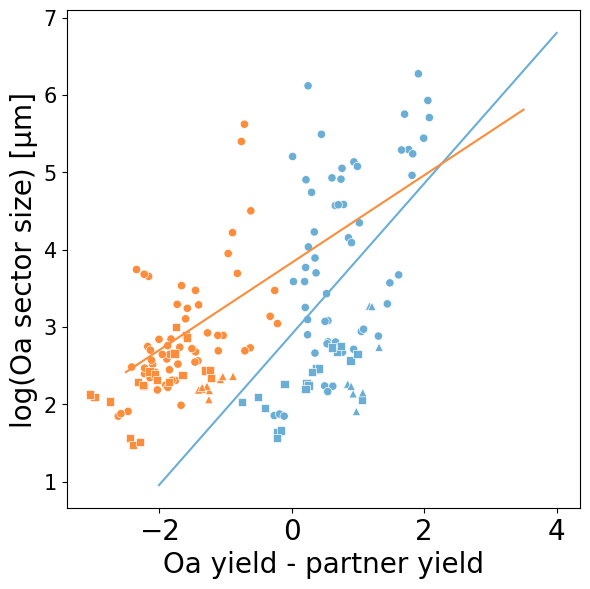

In [28]:
# Mixed model: random intercept for partner
df["rel_yield_centered"] = df["rel_yield"] - df["rel_yield"].mean()

model = smf.mixedlm(
    "log_sector_um ~ rel_yield_centered*C(thiamin)", 
    data=df[df["oa_frequency"]<oa_thresh],
    groups=df[df["oa_frequency"]<oa_thresh]["partner"],
    re_formula="1"
)

result = model.fit(reml=False)
print(result.summary())

# Interclass correlation coefficient (ICC)
var_random = result.cov_re.iloc[0, 0]
var_residual = result.scale
icc = var_random / (var_random + var_residual)
print(f"Interclass correlation coefficient (ICC): {icc:.4f}")

# extract p-value for all terms
intercept_p_value = result.pvalues["Intercept"]
slope_p_value = result.pvalues["rel_yield_centered"]
intercept_thi_p_value = result.pvalues["C(thiamin)[T.1]"]
slope_thi_p_value = result.pvalues["rel_yield_centered:C(thiamin)[T.1]"]

# Exatrct slopes and interxepts from summary
intercept = result.params["Intercept"]
slope_fa = result.params["rel_yield_centered"]
additional_slope_fat = result.params["rel_yield_centered:C(thiamin)[T.1]"]
additional_intercept_fat = result.params["C(thiamin)[T.1]"]
slope_fat = slope_fa + additional_slope_fat
intercept_fat = intercept + additional_intercept_fat

print(f"Intercept -T: {intercept:.02f} (p={intercept_p_value}), Slope FA: {slope_fa:.02f} (p={slope_p_value})")
print(f"Additional intercept +T: {additional_intercept_fat:.02f} (p={intercept_thi_p_value}), additional slope FAT: {additional_slope_fat:.02f} (p={slope_thi_p_value} for an additional contribution)")

# Raw data
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(
    data=df[df["oa_frequency"]<oa_thresh],
    x="rel_yield",
    y="log_sector_um",
    hue="thiamin_str",
    palette={"+T": blues[1], "-T": oranges[1]},
    style="condition",
    markers=["o", "s", "^"],
    ax=ax
)
sns.scatterplot(
    data=df[df["oa_frequency"]>oa_thresh],
    x="rel_yield",
    y="log_sector_um",
    color="gray",
    ax=ax
)
ax.set_xlabel("Oa yield - partner yield")
ax.set_ylabel("log(Oa sector size) [µm]")
x_value_fa = np.linspace(-2.5, 3.5, 100)
x_value_fat = np.linspace(-2, 4, 100)
plt.plot(x_value_fat, intercept_fat + slope_fat * (x_value_fat-df["rel_yield"].mean()), color=blues[1],label="fit FAT")
plt.plot(x_value_fa, intercept + slope_fa * (x_value_fa-df["rel_yield"].mean()), color=oranges[1], label="fit FA")
# handles, labels = ax.get_legend_handles_labels()
# new_handles = handles[1:3] + handles[4:9]
# new_labels = labels[1:3] + labels[4:9]
# plt.legend(handles=new_handles, labels=new_labels, fontsize=12)
plt.legend([],[],frameon=False)
plt.tight_layout()
plt.savefig(plot_dir / f"log_oa_ss_vs_rel_yield.pdf", dpi=300)
plt.show()

In [29]:
np.exp(0.55+0.53)

2.944679551065524

In [30]:
# Variance of fixed-effect predictions
fixed_pred = result.model.exog @ result.fe_params
var_fixed = np.var(fixed_pred)

# Random-intercept variance
var_random = result.cov_re.iloc[0, 0]

# Residual variance
var_resid = result.scale

R2_marginal = var_fixed / (
    var_fixed + var_random + var_resid
)

R2_conditional = (var_fixed + var_random) / (
    var_fixed + var_random + var_resid
)

print("Marginal R²:", R2_marginal)
print("Conditional R²:", R2_conditional)

Marginal R²: 0.2977277726244468
Conditional R²: 0.7117726428352121


## Mixed model of Oa sector vs environmental variables

In [31]:
m_ss_env = mixedlm(
    "log_sector ~ C(carbon_source) + C(salt) + C(thiamin)",
    data=df,
    groups=df["partner"],
    re_formula="1"
)
result_ss_env = m_ss_env.fit(reml=False) # to later compare with lm
print(result_ss_env.summary())

lm_ss_env = smf.ols("log_sector ~ C(carbon_source) + C(salt) + C(thiamin)", data=df).fit()
print(lm_ss_env.summary())

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   log_sector
No. Observations:     174       Method:               ML        
No. Groups:           19        Scale:                0.3199    
Min. group size:      6         Log-Likelihood:       -174.2356 
Max. group size:      18        Converged:            Yes       
Mean group size:      9.2                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              2.778    0.212 13.097 0.000  2.362  3.194
C(carbon_source)[T.1] -0.761    0.173 -4.395 0.000 -1.100 -0.421
C(salt)[T.1]           0.780    0.122  6.376 0.000  0.540  1.020
C(thiamin)[T.1]        0.684    0.086  7.980 0.000  0.516  0.852
Group Var              0.589    0.389                           

                            OLS Regres

In [32]:

# Equivalent ordinary linear model
lm_ss_env = smf.ols(
    "log_sector ~ C(carbon_source) + C(salt) + C(thiamin)",
    data=df
).fit()


# -------------------------
# Compare model fit
# -------------------------

print("OLS")
print("AIC:", lm_ss_env.aic)
print("BIC:", lm_ss_env.bic)
print("Log-likelihood:", lm_ss_env.llf)

print("\nMixed model")
print("AIC:", result_ss_env.aic)
print("BIC:", result_ss_env.bic)
print("Log-likelihood:", result_ss_env.llf)

print("\nDifferences: OLS - Mixed")
print("Delta AIC:", lm_ss_env.aic - result_ss_env.aic)
print("Delta BIC:", lm_ss_env.bic - result_ss_env.bic)
print("Delta log-likelihood:", result_ss_env.llf - lm_ss_env.llf)


# -------------------------
# Size of partner random effect
# -------------------------

# Random-intercept variance
partner_var = result_ss_env.cov_re.iloc[0, 0]

# Random-intercept standard deviation
partner_sd = np.sqrt(partner_var)

# Residual variance
residual_var = result_ss_env.scale
residual_sd = np.sqrt(residual_var)

# ICC: fraction of residual variance attributable to partner
icc = partner_var / (partner_var + residual_var)

print("\nRandom effect")
print("Partner variance:", partner_var)
print("Partner SD:", partner_sd)
print("Residual variance:", residual_var)
print("Residual SD:", residual_sd)
print("ICC:", icc)

# -------------------
# partner random effect over fixed effects
# -------------------
fixed_intercept = result_ss_env.fe_params["Intercept"]
partner_sd = np.sqrt(result_ss_env.cov_re.iloc[0, 0])

relative_partner_sd = partner_sd / abs(fixed_intercept)

print("Partner SD / |intercept|:", relative_partner_sd)

OLS
AIC: 453.391242263566
BIC: 466.02746346042414
Log-likelihood: -222.695621131783

Mixed model
AIC: 360.47123159126954
BIC: 379.42556338655675
Log-likelihood: -174.23561579563477

Differences: OLS - Mixed
Delta AIC: 92.92001067229648
Delta BIC: 86.6019000738674
Delta log-likelihood: 48.46000533614824

Random effect
Partner variance: 0.5888449620179372
Partner SD: 0.7673623407608281
Residual variance: 0.31986998948903267
Residual SD: 0.565570499132542
ICC: 0.6479974397267533
Partner SD / |intercept|: 0.2762404963998822


## Mixed model of Oa sector vs yields and interactions
The purpose of this mixed model is to compare with the linear models od Oa sector size and to quantify partner variability. Therefore, we do not exclude partners for which Oa dominates in +T.

In [33]:
df_complete = pd.concat([df,df_removed])

<AxesSubplot:xlabel='partner', ylabel='log_sector'>

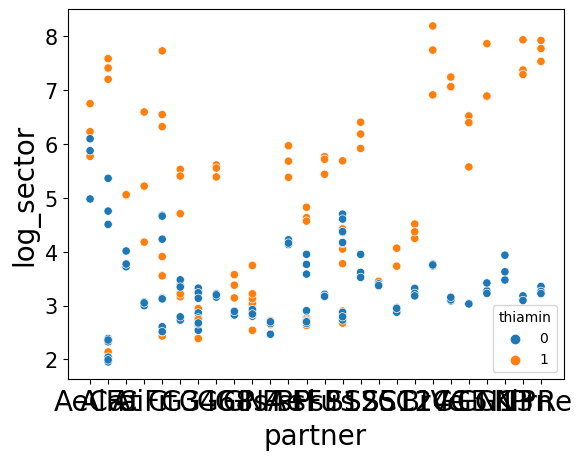

In [34]:
sns.scatterplot(data=df_complete, x="partner", y="log_sector", hue="thiamin")

In [35]:
# Mixed model
m_ss = mixedlm(
    "log_sector ~ oa_on_p + p_on_oa + p_yield + oa_yield",
    data=df_complete,
    groups=df_complete["partner"],
    re_formula="1"
)
result_ss = m_ss.fit(reml=False) # to later compare with lm
print(result_ss.summary())
print(result_ss.cov_re)

# Equivalent ordinary linear model
lm_ss = smf.ols(
    "log_sector ~ oa_on_p + p_on_oa + p_yield + oa_yield",
    data=df_complete
).fit()
print(lm_ss.summary())


# -------------------------
# Compare model fit
# -------------------------

print("OLS")
print("AIC:", lm_ss.aic)
print("BIC:", lm_ss.bic)
print("Log-likelihood:", lm_ss.llf)

print("\nMixed model")
print("AIC:", result_ss.aic)
print("BIC:", result_ss.bic)
print("Log-likelihood:", result_ss.llf)

print("\nDifferences: OLS - Mixed")
print("Delta AIC:", lm_ss.aic - result_ss.aic)
print("Delta BIC:", lm_ss.bic - result_ss.bic)
print("Delta log-likelihood:", result_ss.llf - lm_ss.llf)

llr = 2 * (result_ss.llf - lm_ss.llf)
df_diff = result_ss.df_modelwc - lm_ss.df_model
p_value = chi2.sf(llr, df_diff)
print(f"Log-likelihood ratio test: LLR={llr}, df={df_diff}, p-value={p_value}")
# -------------------------
# Size of partner random effect
# -------------------------

# Random-intercept variance
partner_var = result_ss.cov_re.iloc[0, 0]

# Random-intercept standard deviation
partner_sd = np.sqrt(partner_var)

# Residual variance
residual_var = result_ss.scale
residual_sd = np.sqrt(residual_var)

# ICC: fraction of residual variance attributable to partner
icc = partner_var / (partner_var + residual_var)

print("\nRandom effect")
print("Partner variance:", partner_var)
print("Partner SD:", partner_sd)
print("Residual variance:", residual_var)
print("Residual SD:", residual_sd)
print("ICC:", icc)

# -------------------
# partner random effect over fixed effects
# -------------------
fixed_intercept = result_ss.fe_params["Intercept"]
partner_sd = np.sqrt(result_ss.cov_re.iloc[0, 0])

relative_partner_sd = partner_sd / abs(fixed_intercept)

print("Partner SD / |intercept|:", relative_partner_sd)

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_sector
No. Observations: 231     Method:             ML        
No. Groups:       26      Scale:              0.2954    
Min. group size:  3       Log-Likelihood:     -214.7009 
Max. group size:  18      Converged:          Yes       
Mean group size:  8.9                                   
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     3.329    0.625   5.323 0.000  2.103  4.555
oa_on_p      -1.002    0.077 -12.949 0.000 -1.153 -0.850
p_on_oa       0.871    0.094   9.238 0.000  0.686  1.056
p_yield      -0.967    0.069 -13.918 0.000 -1.103 -0.830
oa_yield      1.009    0.095  10.670 0.000  0.824  1.194
Group Var     0.282    0.173                            

          Group
Group  0.281662
                            OLS Regression Results               

In [38]:
np.exp(0.54)

1.7160068621848585

## Mixed model of mixing vs environmenral variables

/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2202: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  ConvergenceWarning)
/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2202: ConvergenceWarning: Retrying MixedLM optimization with cg
  ConvergenceWarning)


                Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   mean_intermixing
No. Observations:     174       Method:               ML              
No. Groups:           19        Scale:                0.0007          
Min. group size:      6         Log-Likelihood:       370.4512        
Max. group size:      18        Converged:            No              
Mean group size:      9.2                                             
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    0.046    0.005  8.855 0.000  0.036  0.056
C(thiamin)[T.1]             -0.014    0.004 -3.196 0.001 -0.022 -0.005
Group Var                    0.000    0.006                           
Group x C(thiamin)[T.1] Cov -0.000                                    
C(thiamin)[T.1] Var    

/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.300546
  warnings.warn(msg, ConvergenceWarning)
/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


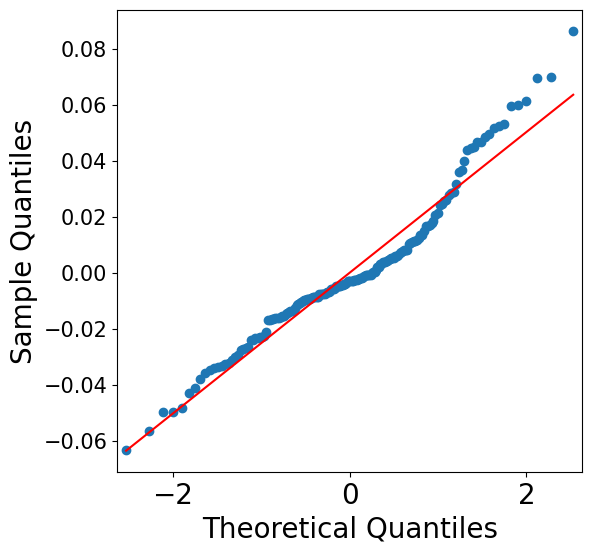

In [36]:
m_mix_env = mixedlm(
    "mean_intermixing ~ C(thiamin)",
    data=df,
    groups=df["partner"],
    re_formula="1 + C(thiamin)"
)
result_mix_env = m_mix_env.fit(reml=False) # to later compare with lm
print(result_mix_env.summary())
print(result_mix_env.cov_re)

# residual analysis
residuals = result_mix_env.resid
# qqplot
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(residuals, line='s',ax=ax)
plt.show()


## Mixed model of mixing vs yields and interactions

In [37]:
# Partner specific slope and intercept
m_mix = mixedlm(
    "mean_intermixing ~  oa_on_p + p_on_oa + p_yield + oa_yield",
    data=df,
    groups=df["partner"],
    re_formula="1"
)

result_mix = m_mix.fit(reml=False) # to later compare with lm
print(result_mix.summary())
print(result_mix.cov_re)

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_intermixing
No. Observations: 174     Method:             ML              
No. Groups:       19      Scale:              0.0006          
Min. group size:  6       Log-Likelihood:     384.6714        
Max. group size:  18      Converged:          Yes             
Mean group size:  9.2                                         
----------------------------------------------------------------
            Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
----------------------------------------------------------------
Intercept   -0.102      0.044   -2.295   0.022   -0.189   -0.015
oa_on_p      0.023      0.008    2.972   0.003    0.008    0.039
p_on_oa      0.004      0.006    0.688   0.491   -0.008    0.017
p_yield      0.030      0.006    4.750   0.000    0.017    0.042
oa_yield     0.003      0.006    0.409   0.683   -0.010    0.015
Group Var    0.000      0.007                       

/home/alessia/anaconda3/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
